<a href="https://colab.research.google.com/github/j-see17/Python-Coding/blob/main/Copy_of_BUMK744_KMeans_Quiz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **K-Means Quiz**
*BUMK744 Marketing Research and Analytics*

**Notes**
- Save your notebook often, in case you get disconnected or the Google Colab environment crashes.
- Save a copy of your notebook. In case of suspicious activity I will ask you for a copy of your notebook.
- You **do not have to submit** your notebook.
- Provide all your answers in 4 decimals precision.

Run the cell below to load the standard packages and the dataset stored in the variable **`X`**
* **You should use the `X` matrix as is. Do not perform any additional transformations on `X` unless specifically instructed!**

In [2]:
# Standard packages
import numpy as np
import pandas as pd

# plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Dataset
from sklearn import datasets

wine = datasets.load_wine()
wine = pd.DataFrame(wine.data, columns=wine.feature_names)

X = (wine - wine.mean()) / wine.std()

print('Head of dataframe:')
print(X.head(), '\n')

print('Means:')
print(X.mean().round(6), '\n')

print('Variances:')
print(X.var().round(6))

Head of dataframe:
    alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
0  1.514341   -0.560668  0.231400          -1.166303   1.908522   
1  0.245597   -0.498009 -0.825667          -2.483841   0.018094   
2  0.196325    0.021172  1.106214          -0.267982   0.088110   
3  1.686791   -0.345835  0.486554          -0.806975   0.928300   
4  0.294868    0.227053  1.835226           0.450674   1.278379   

   total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
0       0.806722    1.031908             -0.657708         1.221438   
1       0.567048    0.731565             -0.818411        -0.543189   
2       0.806722    1.212114             -0.497005         2.129959   
3       2.484437    1.462399             -0.979113         1.029251   
4       0.806722    0.661485              0.226158         0.400275   

   color_intensity       hue  od280/od315_of_diluted_wines   proline  
0         0.251009  0.361158                      1.842721  1.010159  
1        

# Quiz:
- **Important: Do not center or standardize the data yourself**. Use the provided **`X`** variable as-is
- Provide answers to the following questions on Canvas

# Question 1

What is the **primary** objective of applying K-Means clustering in a marketing research study?

Choose from:
> - Classification
> - Dimensionality reduction
> - Prediction
> - Visualization

# Question 2

**Adapt the code (!!!)** in the code cell below to apply **K-Means clustering** on the standardized data `X`.

**Carefully follow these instructions**:
- Use the `KMeans` method from scikit-learn
- Set the number of clusters equal to **`2`**
- Set the random state of the algorithm to **`777`**
- Use **`25`** random starts (initializations)

What is the obtained SSE value?

**`Note`**: Round your answer to two decimal places. For example, if your answer is 12.345, provide 12.35

In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=777, n_init=25)
kmeans.fit(X)

M = pd.DataFrame(kmeans.cluster_centers_, columns=X.columns)
a = pd.Series(kmeans.labels_, index=X.index)


from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=777, n_init=25)
kmeans.fit(X)

sse = kmeans.inertia_
print(round(sse, 2))

1649.44


# Question 3

To answer this question, visualize the K-Means solution obtained in the previous question. Create two scatter plots for the following two pairs of variables:
- Scatterplot 1: `ash` and `magnesium`
- Scatterplot 2: `flavanoids` and `alcohol`

**!!! IMPORTANT !!!**
Code has been provided below to create these scatter plots. The provided code only works if you saved the cluster centroids and cluster assignments as:

```python
M = pd.DataFrame(kmeans.cluster_centers_, columns=X.columns)
a = pd.Series(kmeans.labels_, index=X.index)
```
**Question**:

Consider that your goal is to provide a **clear interpretation** for each cluster identified using the K-Means algorithm.

Based on the two scatter plots, which pair of variables can best be used to differentiate between and interprete the clusters?

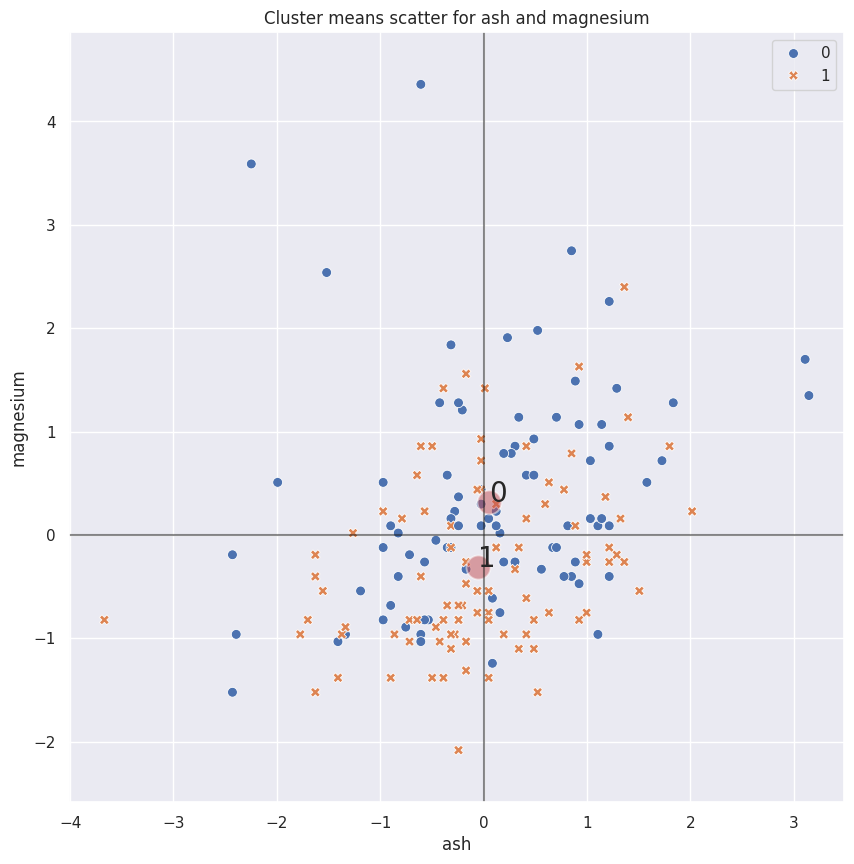

In [6]:
plt.figure(figsize=(10, 10))

# variable names
x_var = 'ash'
y_var = 'magnesium'
plt.title('Cluster means scatter for ' + x_var + ' and ' + y_var)


# create line for the axes
plt.axhline(0, alpha=0.5, color='k')
plt.axvline(0, alpha=0.5, color='k')


# scatterplot for the observations
sns.scatterplot(
    x=x_var,
    y=y_var,
    data=X,
    s=50,
    hue=a,
    style=a,
    legend='full',
)


# scatterplot for the cluster means
sns.scatterplot(
    x=x_var,
    y=y_var,
    data=M,
    s=300,
    color='r',
    alpha=0.5,
)


# add a label for each cluster mean
for k in range(kmeans.n_clusters):
    plt.annotate(
        text=k,
        xy=M.loc[k, [x_var, y_var]],
        fontsize=20
    )

plt.axis('equal')
plt.show()

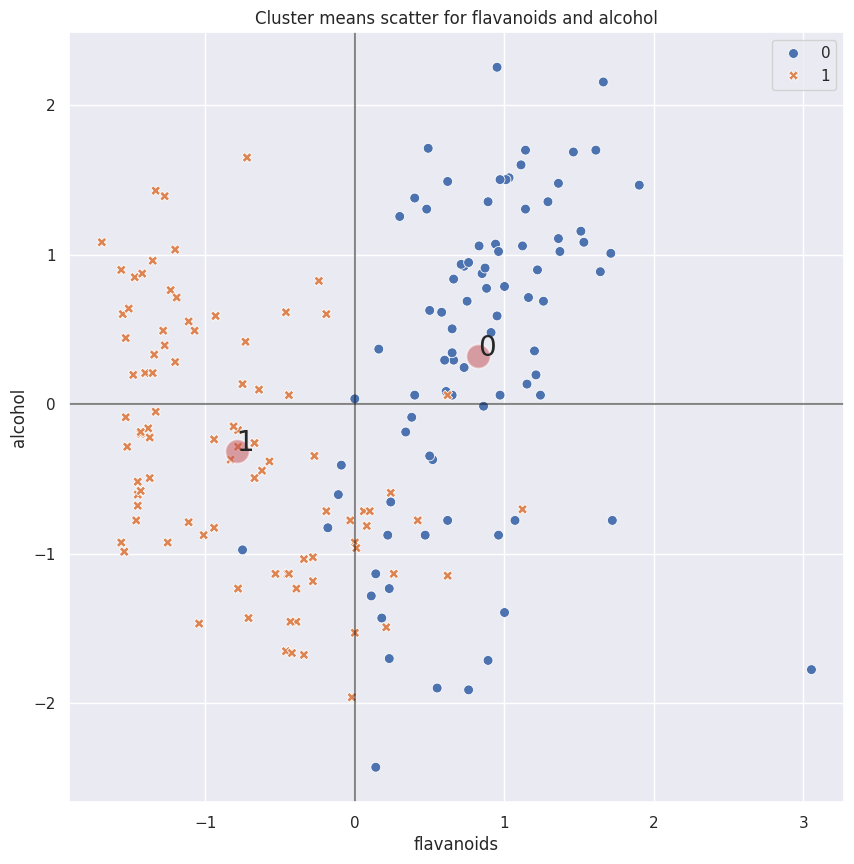

In [7]:
plt.figure(figsize=(10, 10))

# variable names
x_var = 'flavanoids'
y_var = 'alcohol'
plt.title('Cluster means scatter for ' + x_var + ' and ' + y_var)


# create line for the axes
plt.axhline(0, alpha=0.5, color='k')
plt.axvline(0, alpha=0.5, color='k')


# scatterplot for the observations
sns.scatterplot(
    x=x_var,
    y=y_var,
    data=X,
    s=50,
    hue=a,
    style=a,
    legend='full',
)


# scatterplot for the cluster means
sns.scatterplot(
    x=x_var,
    y=y_var,
    data=M,
    s=300,
    color='r',
    alpha=0.5,
)


# add a label for each cluster mean
for k in range(kmeans.n_clusters):
    plt.annotate(
        text=k,
        xy=M.loc[k, [x_var, y_var]],
        fontsize=20
    )

plt.axis('equal')
plt.show()

# Question 4

It could be that two clusters is not optimal. Determine the optimal number of clusters to use in the K-Means algorithm, based on an elbow plot.

**Carefully follow these instructions**:
- Consider **K** values ranging from **`1`** to **`20`**
- Set the random state to **`777`**
- Use **`25`** random starts per **K** value

**`Note`**: Your answer should be an integer, i.e., a whole number without a fractional component. For example, if your answer is 7 clusters, provide **7** as your answer